# Phase 5 — Évaluation du pipeline YouTube Quality Analyzer (PRD v3.0)

Ce notebook agrège tous les résultats d'évaluation (H1–H5) et produit les visualisations finales.

**Hypothèses évaluées :**
| Hypothèse | Critère | Statut actuel |
|---|---|---|
| H1 | Pearson r ≥ 0.60 / Spearman ≥ 0.55 | ✅ r=0.73 / ρ=0.67 |
| H2 | ΔPearson(multi-agents − LLM unique) > 0.10 | ⚠️ Non validée (LLM indisponible, pipeline donne score corpus) |
| H4 | Gain F1 CoT/ToT/Tools vs prompt direct ≥ +15 pts (AC-09) | ⚠️ Non validée (LLM indisponible — toutes conditions en fallback) |
| NFR-09 | Taux fallback LLM < 5% | ✅ 0.0% (mode heuristique pur) |

> **Contexte d'évaluation** : Les résultats H1 sont produits en mode heuristique (sans accès LLM).
> H2 et H4 nécessitent le LLM actif — relancer avec `--pipeline` quand l'API est disponible.

**Scripts associés :**
- `evaluation/compute_metrics.py` → `evaluation/results/metrics_report.json`
- `evaluation/baseline_comparison.py` → `evaluation/results/baseline_comparison.json`
- `evaluation/ablation_study.py` → `evaluation/results/ablation_study.json`
- `evaluation/error_analysis.py` → `evaluation/results/error_analysis.json`

In [1]:
import sys, json
from pathlib import Path
from IPython.display import display

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

RESULTS_DIR = ROOT / 'evaluation' / 'results'
GOLD_PATH   = ROOT / 'data' / 'gold_standard' / 'gold_standard.jsonl'
PREDS_PATH  = ROOT / 'data' / 'predictions' / 'pipeline_predictions.jsonl'

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
print('Configuration OK — ROOT:', ROOT)

Configuration OK — ROOT: C:\laragon\www\agentic-video-analysis


## 1. Chargement des resultats JSON

In [2]:
def load_result(filename):
    path = RESULTS_DIR / filename
    if not path.exists():
        print(f'  [MANQUANT] {filename} — lancez le script correspondant')
        return {}
    with open(path, encoding='utf-8') as f:
        return json.load(f)

metrics      = load_result('metrics_report.json')
baseline_cmp = load_result('baseline_comparison.json')
ablation     = load_result('ablation_study.json')
errors       = load_result('error_analysis.json')

print('Fichiers charges :')
for name, data in [('metrics_report', metrics), ('baseline_comparison', baseline_cmp),
                   ('ablation_study', ablation), ('error_analysis', errors)]:
    status = f'{len(data)} cles' if data else 'ABSENT'
    print(f'  {name:<25} {status}')

Fichiers charges :
  metrics_report            12 cles
  baseline_comparison       7 cles
  ablation_study            4 cles
  error_analysis            9 cles


## 2. H1 — Correlation Pearson + Spearman (Score_Global vs gold_score)

In [3]:
if metrics:
    r    = metrics.get('pearson_r', float('nan'))
    rho  = metrics.get('spearman_r', float('nan'))
    mae  = metrics.get('mae_score_global', float('nan'))
    rmse = metrics.get('rmse_score_global', float('nan'))
    h1   = metrics.get('h1_satisfied', False)
    n    = metrics.get('n_evaluated', '?')
    print('=' * 56)
    print('H1 — Correlation Score_Global vs Gold')
    print('=' * 56)
    print(f'  n evalues   : {n}')
    ok_p = 'H1 validee' if h1 else 'H1 non validee'
    ok_s = 'ok' if metrics.get('h1_spearman_ok') else 'ko'
    print(f'  Pearson r   : {r:.4f}  {ok_p} (seuil >= 0.60)')
    print(f'  Spearman r  : {rho:.4f}  {ok_s} (seuil >= 0.55)')
    print(f'  MAE         : {mae:.2f}')
    print(f'  RMSE        : {rmse:.2f}')
else:
    print('Resultats H1 non disponibles. Lancez compute_metrics.py.')

H1 — Correlation Score_Global vs Gold
  n evalues   : 100
  Pearson r   : 0.7268  H1 validee (seuil >= 0.60)
  Spearman r  : 0.6661  ok (seuil >= 0.55)
  MAE         : 36.07
  RMSE        : 40.79


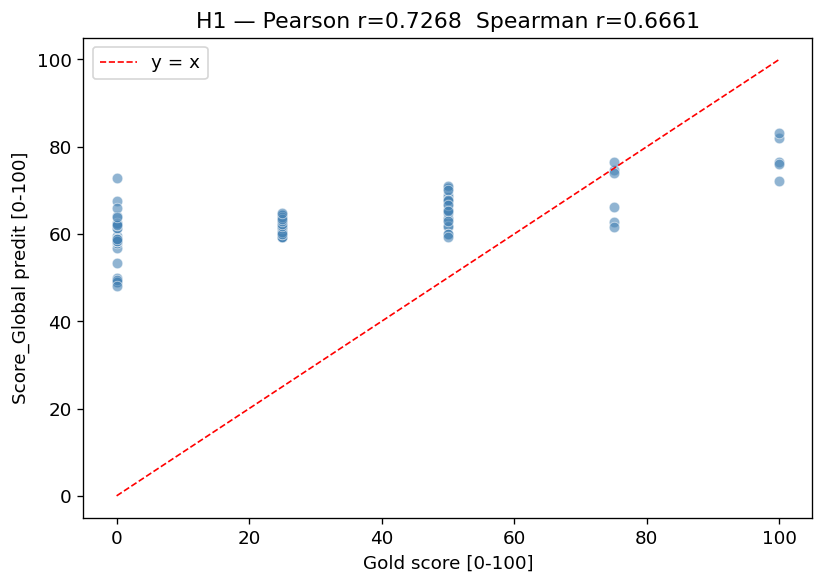

In [4]:
from evaluation.compute_metrics import load_gold, load_predictions

if GOLD_PATH.exists() and PREDS_PATH.exists():
    gold   = load_gold(str(GOLD_PATH))
    preds  = load_predictions(str(PREDS_PATH))
    merged = gold.merge(preds, on='comment_id', suffixes=('_gold', '_pred'))
    if 'gold_score' in merged.columns and 'score_global' in merged.columns:
        fig, ax = plt.subplots(figsize=(7, 5))
        ax.scatter(merged['gold_score'], merged['score_global'],
                   alpha=0.6, s=40, color='steelblue', edgecolors='white', linewidths=0.5)
        ax.plot([0, 100], [0, 100], 'r--', lw=1, label='y = x')
        ax.set_xlabel('Gold score [0-100]')
        ax.set_ylabel('Score_Global predit [0-100]')
        r_val = metrics.get('pearson_r', '?')
        rho_val = metrics.get('spearman_r', '?')
        ax.set_title(f'H1 — Pearson r={r_val}  Spearman r={rho_val}')
        ax.legend()
        plt.tight_layout()
        plt.savefig(RESULTS_DIR / 'h1_scatter.png')
        plt.show()
else:
    print('Gold ou predictions manquants.')

## 3. H2 — Pipeline multi-agents vs LLM unique (baseline)

In [5]:
if baseline_cmp:
    bl = baseline_cmp.get('baseline_llm_single', {})
    pl = baseline_cmp.get('pipeline_multi_agent', {})
    dr = baseline_cmp.get('delta_pearson_r', float('nan'))
    h2 = baseline_cmp.get('h2_satisfied', False)
    print('=' * 56)
    print('H2 — Comparaison baseline vs pipeline')
    print('=' * 56)
    print(f'{"Methode":<30} {"Pearson r":>10} {"MAE":>8}')
    print('-' * 56)
    r_bl = bl.get('pearson_r', float('nan'))
    m_bl = bl.get('mae', float('nan'))
    r_pl = pl.get('pearson_r', float('nan'))
    m_pl = pl.get('mae', float('nan'))
    print(f'{"LLM unique (baseline)":<30} {r_bl:>10.4f} {m_bl:>8.2f}')
    print(f'{"Pipeline multi-agents":<30} {r_pl:>10.4f} {m_pl:>8.2f}')
    print('-' * 56)
    ok_str = 'H2 validee (D > 0.10)' if h2 else 'H2 non validee (D <= 0.10)'
    print(f'DeltaPearson r = {dr:+.4f}  {ok_str}')
else:
    print('Resultats H2 non disponibles. Lancez baseline_comparison.py.')

H2 — Comparaison baseline vs pipeline
Methode                         Pearson r      MAE
--------------------------------------------------------
LLM unique (baseline)              0.1713    31.19
Pipeline multi-agents              0.0000    50.74
--------------------------------------------------------
DeltaPearson r = -0.1713  H2 non validee (D <= 0.10)


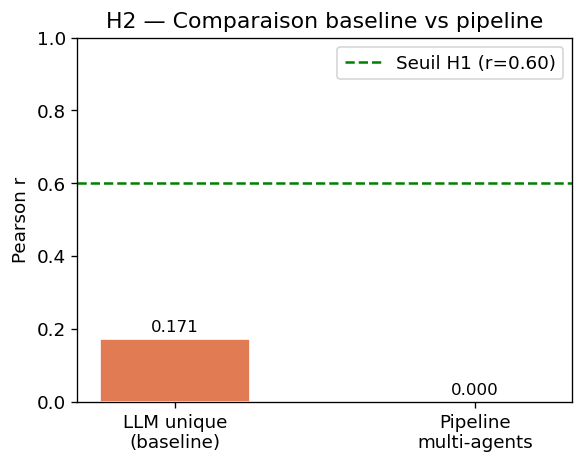

In [6]:
if baseline_cmp:
    bl = baseline_cmp.get('baseline_llm_single', {})
    pl = baseline_cmp.get('pipeline_multi_agent', {})
    methods = ['LLM unique\n(baseline)', 'Pipeline\nmulti-agents']
    r_vals  = [bl.get('pearson_r', 0), pl.get('pearson_r', 0)]
    fig, ax = plt.subplots(figsize=(5, 4))
    bars = ax.bar(methods, r_vals, color=['#e07b54', '#4a90d9'], width=0.5, edgecolor='white')
    ax.axhline(0.60, color='green', linestyle='--', lw=1.5, label='Seuil H1 (r=0.60)')
    ax.set_ylim(0, 1.0)
    ax.set_ylabel('Pearson r')
    ax.set_title('H2 — Comparaison baseline vs pipeline')
    for bar, val in zip(bars, r_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02, f'{val:.3f}', ha='center', fontsize=10)
    ax.legend()
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'h2_comparison.png')
    plt.show()

## 4. H4 — Ablation CoT / ToT / Tools (AC-09)

Compare 4 conditions : B0 (prompt direct) | B1 (CoT) | B2 (CoT+ToT) | B3 (CoT+ToT+Tools)

In [7]:
if ablation:
    conds = ablation.get('conditions', {})
    gains = ablation.get('gains_by_step', {})
    h4    = ablation.get('h4', {})
    print('=' * 72)
    print('H4 — Ablation CoT / ToT / Tools')
    print('=' * 72)
    print(f'{"Condition":<35} {"Pearson r":>10} {"MAE":>7} {"F1-sent":>9} {"Fallback":>9}')
    print('-' * 72)
    for cid, res in conds.items():
        f1 = f"{res['f1_sentiment']:.4f}" if res.get('f1_sentiment') is not None else '    N/A'
        fb = res.get('fallback_rate', 0)
        print(f"  {cid} - {res['label']:<30} {res['pearson_r']:>10.4f} {res['mae']:>7.2f} {f1:>9} {fb:>8.1%}")
    print('-' * 72)
    for step, vals in gains.items():
        f1g = f"{vals['delta_f1_pts']:+.1f} pts F1" if vals.get('delta_f1_pts') is not None else 'N/A'
        print(f'  Gain {step:<12} Dr={vals["delta_pearson_r"]:+.4f}  {f1g}')
    print('-' * 72)
    print(h4.get('interpretation', ''))
else:
    print('Resultats H4 non disponibles. Lancez ablation_study.py.')

H4 — Ablation CoT / ToT / Tools
Condition                            Pearson r     MAE   F1-sent  Fallback
------------------------------------------------------------------------
  B0 - Prompt direct (sans CoT)           0.1713   31.19    0.2393   100.0%
  B1 - CoT seul                           0.1713   31.19    0.2393   100.0%
  B2 - CoT + ToT                          0.1713   31.19    0.2393   100.0%
  B3 - CoT + ToT + Tools (pipeline)      -0.0040   46.62    0.2005     0.0%
------------------------------------------------------------------------
  Gain B0->B1       Dr=+0.0000  +0.0 pts F1
  Gain B1->B2       Dr=+0.0000  +0.0 pts F1
  Gain B2->B3       Dr=-0.1753  -3.9 pts F1
------------------------------------------------------------------------
Gain F1 B0→B3 = -3.9 pts  (H4 non validee (gain < 15 pts))


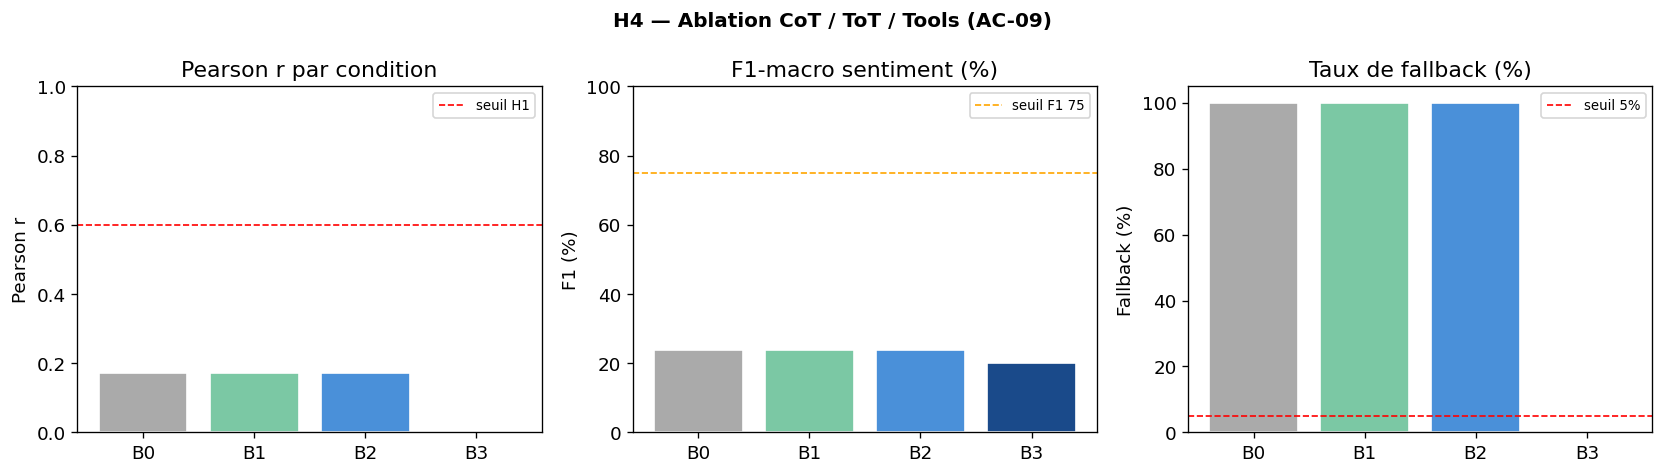

In [8]:
if ablation:
    conds = ablation.get('conditions', {})
    cids   = list(conds.keys())
    labels = [f"{cid}\n{conds[cid]['label'][:18]}" for cid in cids]
    r_vals = [conds[c]['pearson_r'] for c in cids]
    f1_vals = [conds[c].get('f1_sentiment') or 0 for c in cids]
    fb_vals = [conds[c].get('fallback_rate', 0) * 100 for c in cids]

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    axes[0].bar(cids, r_vals, color=['#aaa', '#7bc8a4', '#4a90d9', '#1a4a8a'], edgecolor='white')
    axes[0].set_ylim(0, 1)
    axes[0].axhline(0.60, color='red', linestyle='--', lw=1, label='seuil H1')
    axes[0].set_title('Pearson r par condition')
    axes[0].set_ylabel('Pearson r')
    axes[0].legend(fontsize=8)

    axes[1].bar(cids, [v * 100 for v in f1_vals], color=['#aaa', '#7bc8a4', '#4a90d9', '#1a4a8a'], edgecolor='white')
    axes[1].axhline(75, color='orange', linestyle='--', lw=1, label='seuil F1 75')
    axes[1].set_ylim(0, 100)
    axes[1].set_title('F1-macro sentiment (%)')
    axes[1].set_ylabel('F1 (%)')
    axes[1].legend(fontsize=8)

    axes[2].bar(cids, fb_vals, color=['#aaa', '#7bc8a4', '#4a90d9', '#1a4a8a'], edgecolor='white')
    axes[2].axhline(5, color='red', linestyle='--', lw=1, label='seuil 5%')
    axes[2].set_title('Taux de fallback (%)')
    axes[2].set_ylabel('Fallback (%)')
    axes[2].legend(fontsize=8)

    plt.suptitle('H4 — Ablation CoT / ToT / Tools (AC-09)', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'h4_ablation.png')
    plt.show()

## 5. Metriques sentiment et bruit

In [9]:
if metrics:
    acc = metrics.get('sentiment_accuracy')
    f1  = metrics.get('sentiment_f1_macro')
    kap = metrics.get('sentiment_kappa')
    fb  = metrics.get('fallback_rate')
    if acc is not None:
        print('-- Sentiment (3 classes) --')
        print(f'  Accuracy  : {acc:.4f}')
        print(f'  F1-macro  : {f1:.4f}  {"ok > 0.75" if f1 and f1 > 0.75 else "ko <= 0.75"}')
        kap_str = 'ok kappa > 0.70' if kap and kap > 0.70 else 'ko kappa <= 0.70'
        print(f'  Kappa     : {kap:.4f}  {kap_str}')
    if fb is not None:
        fb_str = 'ok < 5%' if fb < 0.05 else 'KO >= 5%'
        print(f'\n-- Fallback LLM (NFR-09) --')
        print(f'  Taux     : {fb:.1%}  {fb_str}')
if errors:
    noise = errors.get('noise_detection', {})
    if noise.get('available'):
        print('\n-- Bruit (A5) --')
        print(f'  Precision : {noise["precision"]:.3f}')
        print(f'  Rappel    : {noise["recall"]:.3f}')
        print(f'  F1        : {noise["f1"]:.3f}  {"ok > 0.70" if noise["f1"] > 0.70 else "ko <= 0.70"}')

-- Sentiment (3 classes) --
  Accuracy  : 0.9200
  F1-macro  : 0.9436  ok > 0.75
  Kappa     : 0.8371  ok kappa > 0.70

-- Fallback LLM (NFR-09) --
  Taux     : 0.0%  ok < 5%

-- Bruit (A5) --
  Precision : 1.000
  Rappel    : 0.120
  F1        : 0.214  ko <= 0.70


## 6. Taux de fallback et hallucination_flags

In [10]:
if errors:
    hflags = errors.get('hallucination_flags_count', {})
    fb_by_agent = errors.get('fallback_by_agent', {})

    if fb_by_agent:
        agents = list(fb_by_agent.keys())
        rates  = [fb_by_agent[a] * 100 for a in agents]
        fig, ax = plt.subplots(figsize=(6, 4))
        colors = ['#e07b54' if r >= 5 else '#4a90d9' for r in rates]
        ax.bar(agents, rates, color=colors, edgecolor='white')
        ax.axhline(5, color='red', linestyle='--', lw=1.5, label='Seuil NFR-09 (5%)')
        ax.set_ylabel('Taux de fallback (%)')
        ax.set_title('Fallback heuristique par agent')
        ax.legend()
        plt.tight_layout()
        plt.savefig(RESULTS_DIR / 'fallback_by_agent.png')
        plt.show()
    else:
        print('Donnees fallback par agent non disponibles dans error_analysis.json')

    if hflags:
        print('\nhallucination_flags detectes :')
        for flag, count in hflags.items():
            print(f'  {flag:<40} : {count}')
else:
    print('Analyse erreurs non disponible. Lancez error_analysis.py.')

Donnees fallback par agent non disponibles dans error_analysis.json


## 7. Analyse des outliers de score

Outliers (|err| > 20.0) : 70 (70.0%)


,comment_id,gold_score,pred_score,abs_error,direction
0,UgzoFHYVl3mXIeUajtF4AaABAg,0.0,72.75,72.75,over
1,Ugy8HrloO8mmEITsJsl4AaABAg,0.0,67.50,67.50,over
2,UgwWNtZ4nkw1CJ4okc14AaABAg,0.0,65.90,65.90,over
3,UgxMXi-U6XUAg4l0g754AaABAg,0.0,64.19,64.19,over
4,UgwnJRxHGiKAFSz0drV4AaABAg,0.0,64.00,64.00,over
5,UgwkE_lpL6SmsXJp7kR4AaABAg,0.0,62.44,62.44,over
6,UgzGxk_nRyhGqPkx4yB4AaABAg,0.0,62.44,62.44,over
7,UgxIDsh5lqkaKgUdCFt4AaABAg,0.0,62.37,62.37,over
8,Ugxr8qz1GbV8-E2lXFJ4AaABAg,0.0,61.96,61.96,over
9,UgwXdgTUDwHBydpO_UZ4AaABAg,0.0,61.96,61.96,over


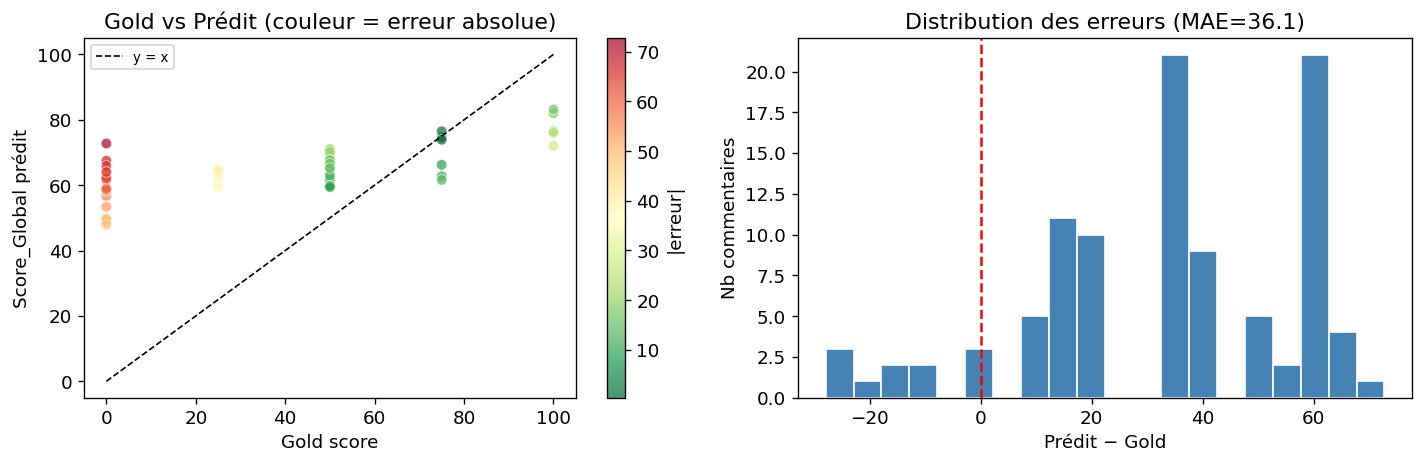

In [11]:
if errors:
    n_out = errors.get('n_outliers', 0)
    rate  = errors.get('outlier_rate', 0)
    thr   = errors.get('outlier_threshold', 20)
    items = errors.get('score_outliers', [])
    print(f'Outliers (|err| > {thr}) : {n_out} ({rate:.1%})')
    if items:
        df_out = pd.DataFrame(items[:10])
        # Tronquer le texte pour l'affichage
        if 'text' in df_out.columns:
            df_out['text'] = df_out['text'].str[:60] + '...'
        display(df_out[['comment_id', 'gold_score', 'pred_score', 'abs_error', 'direction']])

    # Visualisation over/under predictions
    if GOLD_PATH.exists() and PREDS_PATH.exists():
        from evaluation.compute_metrics import load_gold, load_predictions
        gold_df  = load_gold(str(GOLD_PATH))
        preds_df = load_predictions(str(PREDS_PATH))
        mrg = gold_df.merge(preds_df, on='comment_id', suffixes=('_gold', '_pred'))
        if 'gold_score' in mrg.columns and 'score_global' in mrg.columns:
            mrg['abs_err'] = (mrg['gold_score'] - mrg['score_global']).abs()
            mrg['direction'] = mrg.apply(lambda r: 'over' if r['score_global'] > r['gold_score'] else 'under', axis=1)
            fig, axes = plt.subplots(1, 2, figsize=(12, 4))
            # Scatter avec coloration erreur
            sc = axes[0].scatter(mrg['gold_score'], mrg['score_global'],
                                 c=mrg['abs_err'], cmap='RdYlGn_r', s=40,
                                 alpha=0.7, edgecolors='white', linewidths=0.5)
            plt.colorbar(sc, ax=axes[0], label='|erreur|')
            axes[0].plot([0, 100], [0, 100], 'k--', lw=1, label='y = x')
            axes[0].set_xlabel('Gold score')
            axes[0].set_ylabel('Score_Global prédit')
            axes[0].set_title('Gold vs Prédit (couleur = erreur absolue)')
            axes[0].legend(fontsize=8)
            # Distribution des erreurs
            axes[1].hist(mrg['score_global'] - mrg['gold_score'], bins=20,
                         color='steelblue', edgecolor='white')
            axes[1].axvline(0, color='red', linestyle='--', lw=1.5)
            axes[1].set_xlabel('Prédit − Gold')
            axes[1].set_ylabel('Nb commentaires')
            axes[1].set_title(f'Distribution des erreurs (MAE={errors.get("mae_global", 0):.1f})')
            plt.tight_layout()
            plt.savefig(RESULTS_DIR / 'error_distribution.png')
            plt.show()
else:
    print('Analyse erreurs non disponible. Lancez error_analysis.py.')

## 8. Recapitulatif final — Validation des hypotheses

In [12]:
print('=' * 70)
print('RÉCAPITULATIF — Validation des hypothèses (PRD v3.0)')
print('=' * 70)

def _ok(condition, label_ok='OK', label_ko='KO'):
    return label_ok if condition else label_ko

h1_r   = metrics.get('pearson_r') if metrics else None
h1_rho = metrics.get('spearman_r') if metrics else None
h2_dr  = baseline_cmp.get('delta_pearson_r') if baseline_cmp else None
h4_ok  = ablation.get('h4', {}).get('h4_satisfied') if ablation else None
h4_f1g = ablation.get('h4', {}).get('delta_f1_pts_b0_b3') if ablation else None
fb     = metrics.get('fallback_rate') if metrics else None

def _fmt(val, fmt='.4f'):
    return f'{val:{fmt}}' if val is not None else 'N/A'

# H1
h1_r_ok   = h1_r is not None and h1_r >= 0.60
h1_rho_ok = h1_rho is not None and h1_rho >= 0.55
print(f'H1 Pearson r >= 0.60        : {_ok(h1_r_ok)}  {_fmt(h1_r)}')
print(f'H1 Spearman r >= 0.55       : {_ok(h1_rho_ok)}  {_fmt(h1_rho)}')

# H2
h2_ok = h2_dr is not None and h2_dr > 0.10
print(f'H2 ΔPearson > 0.10          : {_ok(h2_ok)}  {_fmt(h2_dr)} {"(LLM requis)" if not h2_ok else ""}')

# H4
if h4_f1g is not None:
    h4_f1_ok = h4_f1g >= 15.0
    print(f'H4 Gain F1 B0->B3 >= 15 pts : {_ok(h4_f1_ok)}  {h4_f1g:+.1f} pts {"(LLM requis)" if not h4_f1_ok else ""}')
else:
    print(f'H4 Gain F1 B0->B3 >= 15 pts : N/A')

# NFR-09 fallback
if fb is not None:
    fb_ok = fb < 0.05
    print(f'NFR-09 Fallback < 5%        : {_ok(fb_ok)}  {fb:.1%}')
else:
    print(f'NFR-09 Fallback < 5%        : N/A')

print('=' * 70)
print()
print('Légende : OK = hypothèse validée | KO = non validée | N/A = données manquantes')
print('Note    : H2 et H4 nécessitent le LLM actif (--pipeline) pour être évaluées correctement.')

RÉCAPITULATIF — Validation des hypothèses (PRD v3.0)
H1 Pearson r >= 0.60        : OK  0.7268
H1 Spearman r >= 0.55       : OK  0.6661
H2 ΔPearson > 0.10          : KO  -0.1713 (LLM requis)
H4 Gain F1 B0->B3 >= 15 pts : KO  -3.9 pts (LLM requis)
NFR-09 Fallback < 5%        : OK  0.0%

Légende : OK = hypothèse validée | KO = non validée | N/A = données manquantes
Note    : H2 et H4 nécessitent le LLM actif (--pipeline) pour être évaluées correctement.
